In [11]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import os

#RESULTS_PATH = r"D:\Users\satri\Pictures\github\Deep-Learning-Robustness-Study\notebook\LSTM\lstm_results_final_base.jsonl"
RESULTS_PATH = r"/home/daniel/Documenti/GitHub/Deep-Learning-Robustness-Study/notebook/LSTM/new_experiments/lstm_results_new.jsonl"

PLOTS_PATH   = "PLOTS_LSTM"
os.makedirs(PLOTS_PATH, exist_ok=True)

df = pd.read_json(RESULTS_PATH, lines=True)
print(f"✅ Run caricati: {len(df)}")
print(df.groupby(['noise_type', 'feature']).size().to_string())
#somma dei tempi di esecuzione
total_time = df['duration_s'].sum()
print(f"⏱️ Tempo totale di esecuzione: {(total_time/60)/60} ore")

✅ Run caricati: 320
noise_type  feature       
duplicated  target1           80
missing     TP3_Reservoirs    80
noise       TP3_Reservoirs    80
outliers    TP3_Reservoirs    80
⏱️ Tempo totale di esecuzione: 11.8756 ore


In [12]:
# N_RUNS = 20  # run reali per combinazione
# T_CRIT = stats.t.ppf(0.975, df=N_RUNS - 1)  # df=19, come prima

# baseline_runs = df[df['percentage'] == 0.0]

# global_baseline_f1     = baseline_runs['f1'].mean()
# global_baseline_auc    = baseline_runs['auc'].mean()
# global_baseline_f1_ci  = T_CRIT * baseline_runs['f1'].std(ddof=1) / np.sqrt(N_RUNS)
# global_baseline_auc_ci = T_CRIT * baseline_runs['auc'].std(ddof=1) / np.sqrt(N_RUNS)

# print(f"Baseline ({len(baseline_runs)} run a 0%)")
# print(f"  F1  : {global_baseline_f1:.4f} ± {global_baseline_f1_ci:.4f}")
# print(f"  AUC : {global_baseline_auc:.4f} ± {global_baseline_auc_ci:.4f}")

# def aggregate(group):
#     n        = len(group)  # dovrebbe essere 20
#     f1_mean  = group['f1'].mean()
#     f1_ci    = T_CRIT * group['f1'].std(ddof=1) / np.sqrt(n)
#     auc_mean = group['auc'].mean()
#     auc_ci   = T_CRIT * group['auc'].std(ddof=1) / np.sqrt(n)
#     return pd.Series({'f1_mean': f1_mean, 'f1_ci': f1_ci,
#                       'auc_mean': auc_mean, 'auc_ci': auc_ci})

In [13]:
# Baseline già nota da lstm_results_final.jsonl
global_baseline_f1     = 0.9739
global_baseline_auc    = 0.9638
global_baseline_f1_ci  = 0.0050
global_baseline_auc_ci = 0.0101

print(f"Baseline (da lstm_results_final, 20 run a 0%)")
print(f"  F1  : {global_baseline_f1:.4f} ± {global_baseline_f1_ci:.4f}")
print(f"  AUC : {global_baseline_auc:.4f} ± {global_baseline_auc_ci:.4f}")

N_RUNS = 20
T_CRIT = stats.t.ppf(0.975, df=N_RUNS - 1)  # df=19

def aggregate(group):
    n        = len(group)
    f1_mean  = group['f1'].mean()
    f1_ci    = T_CRIT * group['f1'].std(ddof=1) / np.sqrt(n)
    auc_mean = group['auc'].mean()
    auc_ci   = T_CRIT * group['auc'].std(ddof=1) / np.sqrt(n)
    return pd.Series({'f1_mean': f1_mean, 'f1_ci': f1_ci,
                      'auc_mean': auc_mean, 'auc_ci': auc_ci})

agg = (df[df['percentage'] > 0.0]
       .groupby(['noise_type', 'feature', 'percentage'])
       .apply(aggregate, include_groups=False)
       .reset_index())

Baseline (da lstm_results_final, 20 run a 0%)
  F1  : 0.9739 ± 0.0050
  AUC : 0.9638 ± 0.0101


In [14]:
# NOISE_TYPES = ['duplicated', 'labels', 'missing', 'noise', 'outliers']
# NOISE_LABELS = {
#     'duplicated': 'Duplicated', 'labels': 'Labels',
#     'missing': 'Missing', 'noise': 'Noisy', 'outliers': 'Outliers'
# }
# FEATURE_COLORS = {
#     'all':                    '#2c7bb6',
#     'DV_pressure_scaled':     '#d7191c',
#     'Oil_temperature_scaled': '#1a9641',
#     'TP3_scaled':             '#ff7f00'
# }
# FEATURE_LABELS = {
#     'all':                    'All features',
#     'DV_pressure_scaled':     'DV_pressure',
#     'Oil_temperature_scaled': 'Oil_temperature',
#     'TP3_scaled':             'TP3'
# }
# PERCENTAGES = [0.0, 0.1, 0.2, 0.3, 0.5]
# PERC_LABELS = ['0%', '10%', '20%', '30%', '50%']
# PADDING = 0.01

# def prepend_baseline(feat_data, metric, b_val, b_ci):
#     x  = [0.0]   + list(feat_data['percentage'])
#     y  = [b_val] + list(feat_data[f'{metric}_mean'])
#     ci = [b_ci]  + list(feat_data[f'{metric}_ci'])
#     return np.array(x), np.array(y), np.array(ci)

# def dynamic_ylim(ax, pad=PADDING):
#     y_min, y_max = np.inf, -np.inf
#     for line in ax.get_lines():
#         yd = line.get_ydata()
#         if len(yd):
#             y_min = min(y_min, np.nanmin(yd))
#             y_max = max(y_max, np.nanmax(yd))
#     for coll in ax.collections:
#         try:
#             for p in coll.get_paths():
#                 verts = p.vertices[:, 1]
#                 y_min = min(y_min, np.nanmin(verts))
#                 y_max = max(y_max, np.nanmax(verts))
#         except Exception:
#             pass
#     if not (np.isinf(y_min) or np.isinf(y_max)):
#         ax.set_ylim(y_min - pad, y_max + pad)

# print("✅ Costanti e helper definiti")

In [15]:
NOISE_TYPES = ['duplicated', 'missing', 'noise', 'outliers']
NOISE_LABELS = {
    'duplicated': 'Duplicated (target=1)',
    'missing':    'Missing',
    'noise':      'Noisy',
    'outliers':   'Outliers'
}
FEATURE_COLORS = {
    'target1':         '#2c7bb6',
    'TP3_Reservoirs':  '#9b59b6',
}
FEATURE_LABELS = {
    'target1':         'Target (fault=1)',
    'TP3_Reservoirs':  'TP3 + Reservoirs',
}
PERCENTAGES = [0.0, 0.1, 0.2, 0.3, 0.5]
PERC_LABELS = ['0%', '10%', '20%', '30%', '50%']
PADDING = 0.01


def prepend_baseline(feat_data, metric, b_val, b_ci):
    x  = [0.0]   + list(feat_data['percentage'])
    y  = [b_val] + list(feat_data[f'{metric}_mean'])
    ci = [b_ci]  + list(feat_data[f'{metric}_ci'])
    return np.array(x), np.array(y), np.array(ci)

def dynamic_ylim(ax, pad=PADDING):
    y_min, y_max = np.inf, -np.inf
    for line in ax.get_lines():
        yd = line.get_ydata()
        if len(yd):
            y_min = min(y_min, np.nanmin(yd))
            y_max = max(y_max, np.nanmax(yd))
    for coll in ax.collections:
        try:
            for p in coll.get_paths():
                verts = p.vertices[:, 1]
                y_min = min(y_min, np.nanmin(verts))
                y_max = max(y_max, np.nanmax(verts))
        except Exception:
            pass
    if not (np.isinf(y_min) or np.isinf(y_max)):
        ax.set_ylim(y_min - pad, y_max + pad)

print("✅ Costanti e helper definiti")

✅ Costanti e helper definiti


In [16]:
# def plot_metric_grid(metric, ylabel, title_suffix, filename):
#     fig, axes = plt.subplots(2, 3, figsize=(16, 10))
#     axes = axes.flatten()

#     for idx, noise_type in enumerate(NOISE_TYPES):
#         ax     = axes[idx]
#         subset = agg[agg['noise_type'] == noise_type]

#         for feat in sorted(subset['feature'].unique()):
#             fd    = subset[subset['feature'] == feat].sort_values('percentage')
#             color = FEATURE_COLORS.get(feat, 'gray')
#             label = FEATURE_LABELS.get(feat, feat)
#             b_val = global_baseline_f1    if metric == 'f1' else global_baseline_auc
#             b_ci  = global_baseline_f1_ci if metric == 'f1' else global_baseline_auc_ci
#             x, y, ci = prepend_baseline(fd, metric, b_val, b_ci)

#             ax.plot(x, y, marker='o', color=color, label=label, linewidth=2)
#             ax.fill_between(x, y - ci, y + ci, alpha=0.15, color=color)

#         ax.set_title(NOISE_LABELS[noise_type], fontsize=13, fontweight='bold')
#         ax.set_xlabel('Percentuale di rumore', fontsize=10)
#         ax.set_ylabel(ylabel, fontsize=10)
#         ax.set_xticks(PERCENTAGES)
#         ax.set_xticklabels(PERC_LABELS)
#         dynamic_ylim(ax)
#         ax.legend(fontsize=9)
#         ax.grid(True, alpha=0.3)

#     axes[5].set_visible(False)
#     plt.suptitle(
#         f'LSTM — Degradazione {title_suffix} per tipo di rumore\n'
#         f'(MetroPT-3, 20 run per punto, IC 95%)',
#         fontsize=14, fontweight='bold', y=1.01
#     )
#     plt.tight_layout()
#     out = os.path.join(PLOTS_PATH, filename)
#     plt.savefig(out, dpi=150, bbox_inches='tight')
#     plt.show()
#     print(f"✅ Salvato: {out}")

# plot_metric_grid('f1',  'F1-score (media ± IC 95%)', 'F1-score', 'lstm_f1_degradation.png')
# plot_metric_grid('auc', 'AUC-ROC (media ± IC 95%)',  'AUC-ROC',  'lstm_auc_degradation.png')

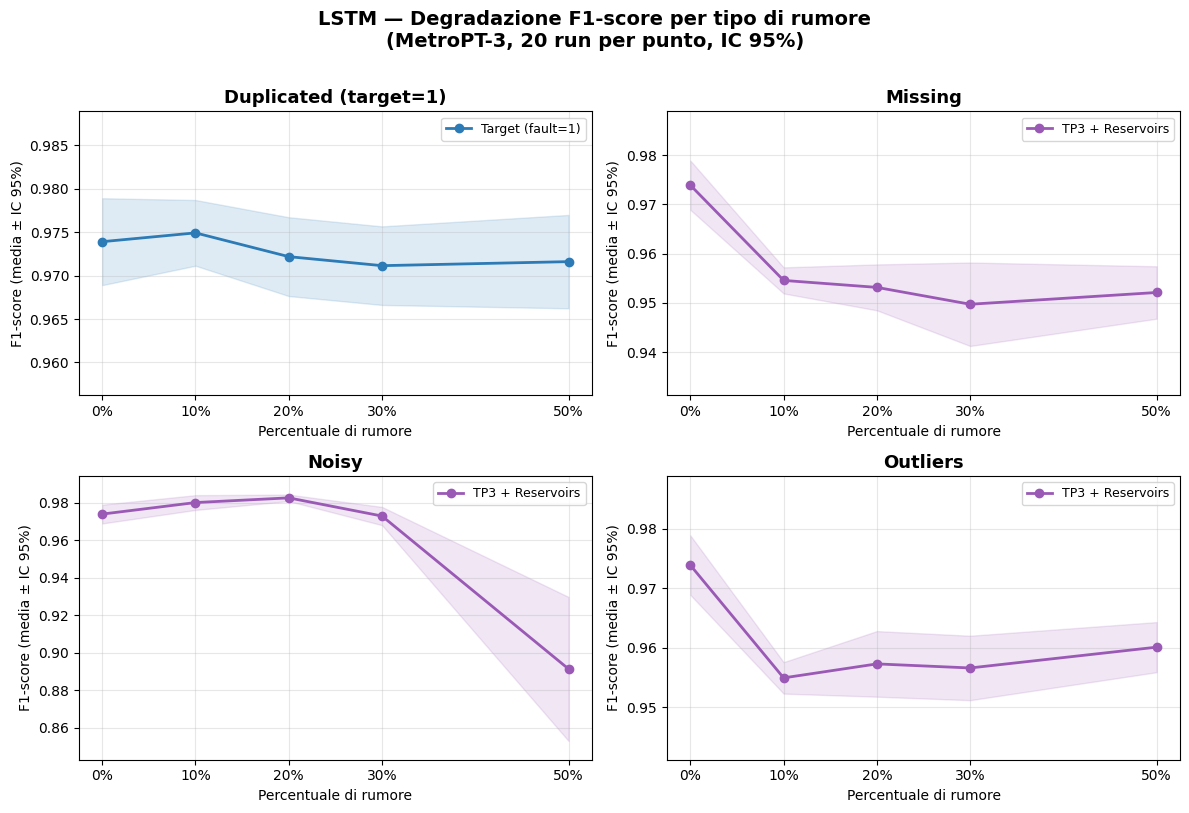

✅ Salvato: PLOTS_LSTM/lstm_new_f1_degradation.png


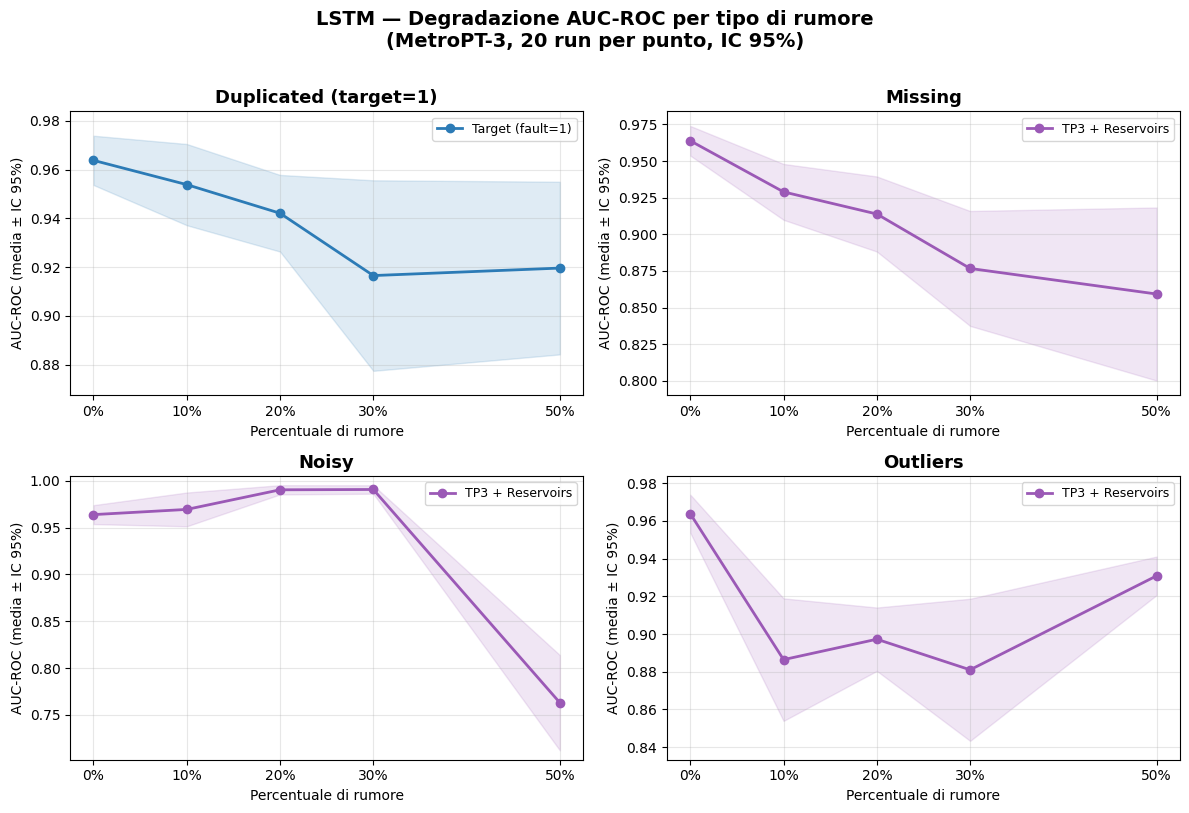

✅ Salvato: PLOTS_LSTM/lstm_new_auc_degradation.png


In [17]:
def plot_metric_grid(metric, ylabel, title_suffix, filename):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for idx, noise_type in enumerate(NOISE_TYPES):
        ax     = axes[idx]
        subset = agg[agg['noise_type'] == noise_type]

        for feat in sorted(subset['feature'].unique()):
            fd    = subset[subset['feature'] == feat].sort_values('percentage')
            color = FEATURE_COLORS.get(feat, 'gray')
            label = FEATURE_LABELS.get(feat, feat)
            b_val = global_baseline_f1    if metric == 'f1' else global_baseline_auc
            b_ci  = global_baseline_f1_ci if metric == 'f1' else global_baseline_auc_ci
            x, y, ci = prepend_baseline(fd, metric, b_val, b_ci)

            ax.plot(x, y, marker='o', color=color, label=label, linewidth=2)
            ax.fill_between(x, y - ci, y + ci, alpha=0.15, color=color)

        ax.set_title(NOISE_LABELS[noise_type], fontsize=13, fontweight='bold')
        ax.set_xlabel('Percentuale di rumore', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_xticks(PERCENTAGES)
        ax.set_xticklabels(PERC_LABELS)
        dynamic_ylim(ax)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'LSTM — Degradazione {title_suffix} per tipo di rumore\n'
        f'(MetroPT-3, 20 run per punto, IC 95%)',
        fontsize=14, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    out = os.path.join(PLOTS_PATH, filename)
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Salvato: {out}")

plot_metric_grid('f1',  'F1-score (media ± IC 95%)', 'F1-score', 'lstm_new_f1_degradation.png')
plot_metric_grid('auc', 'AUC-ROC (media ± IC 95%)',  'AUC-ROC',  'lstm_new_auc_degradation.png')

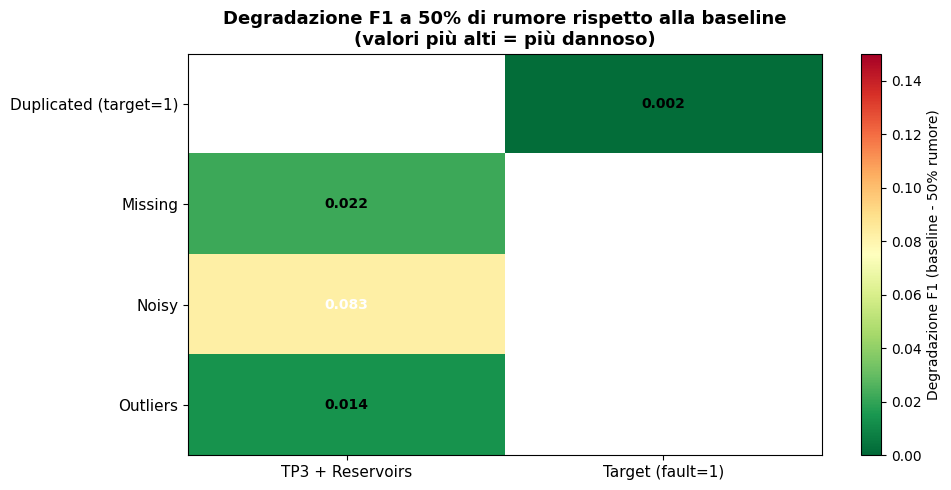

✅ Salvato: PLOTS_LSTM/lstm_new_heatmap_f1.png


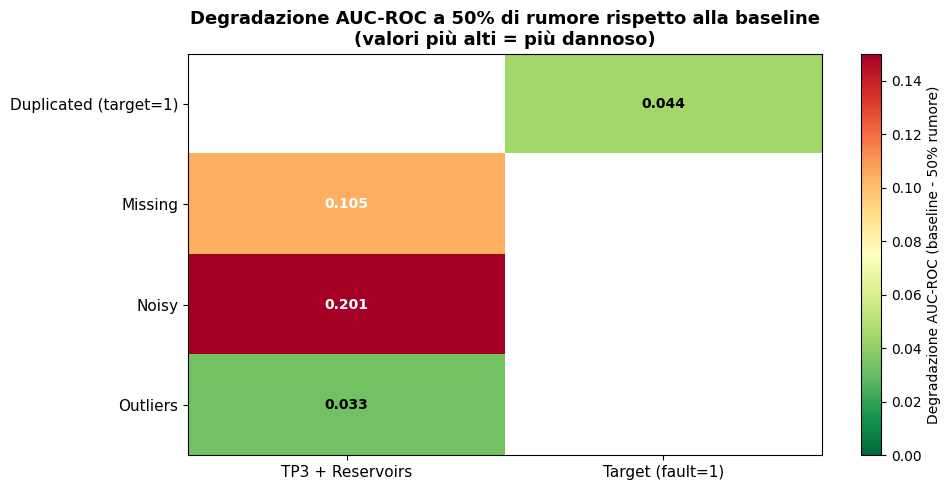

✅ Salvato: PLOTS_LSTM/lstm_new_heatmap_auc.png


In [18]:
def plot_heatmap(metric, baseline_val, label, filename):
    rows = []
    for noise_type in NOISE_TYPES:
        subset = agg[agg['noise_type'] == noise_type]
        for feat in subset['feature'].unique():
            at50 = subset[(subset['feature'] == feat) & (subset['percentage'] == 0.5)][f'{metric}_mean'].values
            if len(at50) > 0:
                rows.append({
                    'noise_type':  NOISE_LABELS[noise_type],
                    'feature':     FEATURE_LABELS.get(feat, feat),
                    'degradation': baseline_val - at50[0]
                })

    heat_df = pd.DataFrame(rows).pivot(index='noise_type', columns='feature', values='degradation')

    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(heat_df.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=0.15)
    plt.colorbar(im, ax=ax, label=f'Degradazione {label} (baseline - 50% rumore)')
    ax.set_xticks(range(len(heat_df.columns)))
    ax.set_yticks(range(len(heat_df.index)))
    ax.set_xticklabels(heat_df.columns, fontsize=11)
    ax.set_yticklabels(heat_df.index, fontsize=11)
    for i in range(len(heat_df.index)):
        for j in range(len(heat_df.columns)):
            val = heat_df.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                        fontsize=10, fontweight='bold',
                        color='white' if abs(val) > 0.08 else 'black')
    ax.set_title(f'Degradazione {label} a 50% di rumore rispetto alla baseline\n(valori più alti = più dannoso)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    out = os.path.join(PLOTS_PATH, filename)
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Salvato: {out}")

plot_heatmap('f1',  global_baseline_f1,  'F1',     'lstm_new_heatmap_f1.png')
plot_heatmap('auc', global_baseline_auc, 'AUC-ROC','lstm_new_heatmap_auc.png')

In [19]:
table = agg.copy()
table['F1 mean ± CI 95%']  = table.apply(lambda r: f"{r['f1_mean']:.4f} ± {r['f1_ci']:.4f}", axis=1)
table['AUC mean ± CI 95%'] = table.apply(lambda r: f"{r['auc_mean']:.4f} ± {r['auc_ci']:.4f}", axis=1)
table['noise_type'] = table['noise_type'].map(NOISE_LABELS)
table['feature']    = table['feature'].map(FEATURE_LABELS)
table['percentage'] = table['percentage'].round(2).map({0.1:'10%', 0.2:'20%', 0.3:'30%', 0.5:'50%'})

table_out = table[['noise_type','feature','percentage','F1 mean ± CI 95%','AUC mean ± CI 95%']]
table_out.columns = ['Noise Type','Feature','Noise %','F1 mean ± CI 95%','AUC mean ± CI 95%']

baseline_row = pd.DataFrame([{
    'Noise Type':        'Baseline',
    'Feature':           'All features',
    'Noise %':           '0%',
    'F1 mean ± CI 95%':  f"{global_baseline_f1:.4f} ± {global_baseline_f1_ci:.4f}",
    'AUC mean ± CI 95%': f"{global_baseline_auc:.4f} ± {global_baseline_auc_ci:.4f}",
}])

table_out = pd.concat([baseline_row, table_out], ignore_index=True)
table_out.to_csv(os.path.join(PLOTS_PATH, 'lstm_new_results_aggregated.csv'), index=False)
print(table_out.to_string(index=False))
print(f"\n✅ Salvato: lstm_results_aggregated.csv")

           Noise Type          Feature Noise % F1 mean ± CI 95% AUC mean ± CI 95%
             Baseline     All features      0%  0.9739 ± 0.0050   0.9638 ± 0.0101
Duplicated (target=1) Target (fault=1)     10%  0.9749 ± 0.0038   0.9539 ± 0.0166
Duplicated (target=1) Target (fault=1)     20%  0.9722 ± 0.0045   0.9421 ± 0.0157
Duplicated (target=1) Target (fault=1)     30%  0.9711 ± 0.0045   0.9166 ± 0.0391
Duplicated (target=1) Target (fault=1)     50%  0.9716 ± 0.0054   0.9196 ± 0.0354
              Missing TP3 + Reservoirs     10%  0.9546 ± 0.0026   0.9289 ± 0.0191
              Missing TP3 + Reservoirs     20%  0.9531 ± 0.0047   0.9138 ± 0.0256
              Missing TP3 + Reservoirs     30%  0.9497 ± 0.0085   0.8767 ± 0.0392
              Missing TP3 + Reservoirs     50%  0.9521 ± 0.0053   0.8592 ± 0.0590
                Noisy TP3 + Reservoirs     10%  0.9800 ± 0.0039   0.9693 ± 0.0180
                Noisy TP3 + Reservoirs     20%  0.9825 ± 0.0017   0.9903 ± 0.0049
                